## Uploading Files

In [ ]:
from google.colab import files

uploaded = files.upload()

## BaseLine Model

X shape: (200, 1)
Y shape: (200, 200)

Train size: 160
Test size : 40
WaveMLP(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=200, bias=True)
  )
)
Epoch    0 | Loss = 0.50197572
Epoch  100 | Loss = 0.02415873
Epoch  200 | Loss = 0.01639711
Epoch  300 | Loss = 0.00037405
Epoch  400 | Loss = 0.00024684
Epoch  500 | Loss = 0.00023375
Epoch  600 | Loss = 0.00021063
Epoch  700 | Loss = 0.00018266
Epoch  800 | Loss = 0.00014768
Epoch  900 | Loss = 0.00010677

Test MSE:
0.001803293009288609


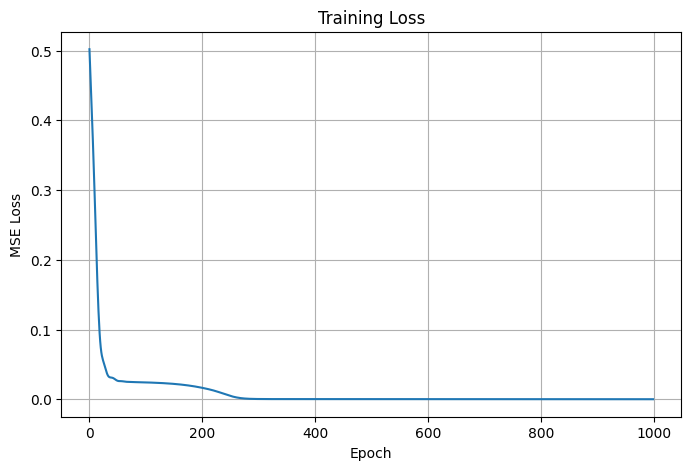


Probability checks:
Sample 0: P = 1.039418
Sample 1: P = 1.041417
Sample 2: P = 1.043455
Sample 3: P = 1.045530
Sample 4: P = 1.047643


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load reshaped dataset
df = pd.read_csv("tdse_particle_in_box_reshaped.csv")

# Create X and Y
X = df[["t"]].values.astype(np.float32)

Y = df.drop(columns=["t"]).values.astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Train/Test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Convert to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# Baseline MLP
class WaveMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(1, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 200)
        )

    def forward(self, x):

        return self.network(x)


model = WaveMLP()

torch.manual_seed(42)
np.random.seed(42)

print(model)

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training loop
epochs = 1000

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(predictions, Y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss = {loss.item():.8f}"
        )

# Test evaluation
model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = criterion(
        test_predictions,
        Y_test
    )

print("\nTest MSE:")
print(test_loss.item())

# Plot training loss
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

# Probability check
dx = 1.0 / 99

test_np = test_predictions.numpy()

print("\nProbability checks:")

for i in range(5):

    sample = test_np[i]

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    print(f"Sample {i}: P = {P:.6f}")

## Baseline Model plus Hard Constraint

X shape: (200, 1)
Y shape: (200, 200)

Train size: 160
Test size : 40
ProbabilityPreservingMLP(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=200, bias=True)
  )
)
Epoch    0 | Loss = 0.96773565
Epoch  100 | Loss = 0.02266201
Epoch  200 | Loss = 0.00171259
Epoch  300 | Loss = 0.00002201
Epoch  400 | Loss = 0.00001177
Epoch  500 | Loss = 0.00000695
Epoch  600 | Loss = 0.00000525
Epoch  700 | Loss = 0.00000478
Epoch  800 | Loss = 0.00000468
Epoch  900 | Loss = 0.00000466

Test MSE:
0.0020231495145708323

Probability checks:
Sample 0: P = 0.999999940395
Sample 1: P = 0.999999940395
Sample 2: P = 0.999999940395
Sample 3: P = 0.999999821186
Sample 4: P = 1.000000119209


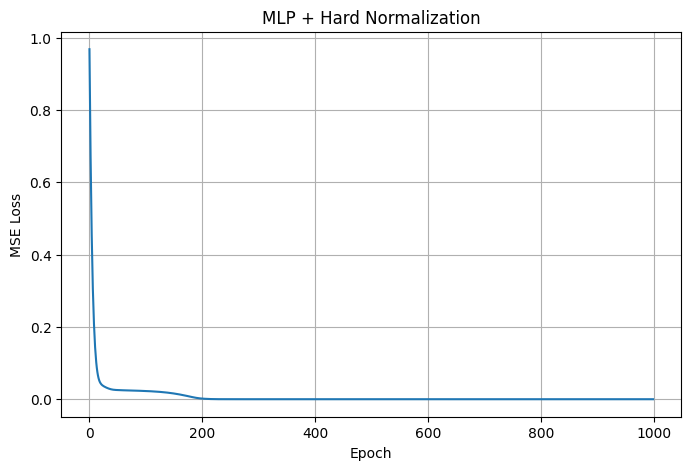

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load reshaped dataset
df = pd.read_csv("tdse_particle_in_box_reshaped.csv")

X = df[["t"]].values.astype(np.float32)
Y = df.drop(columns=["t"]).values.astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Train/Test split (temporal split)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Convert to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# MLP + Hard Probability Constraint
class ProbabilityPreservingMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(1, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 200)
        )

        # Spatial spacing
        self.dx = 1.0 / 99


    def forward(self, x):


        # Raw prediction
        psi_hat = self.network(x)

        # First 100 = real part
        real = psi_hat[:, :100]

        # Last 100 = imaginary part
        imag = psi_hat[:, 100:]


        # Compute total probability
        probability = torch.sum(
            real**2 + imag**2,
            dim=1,
            keepdim=True
        ) * self.dx


        # Hard normalization
        normalization_factor = torch.sqrt(
            probability + 1e-12
        )

        real = real / normalization_factor
        imag = imag / normalization_factor

        # Combine again
        psi = torch.cat([real, imag], dim=1)

        return psi


model = ProbabilityPreservingMLP()

print(model)

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training
epochs = 1000

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(predictions, Y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss = {loss.item():.8f}"
        )

# Test evaluation
model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = criterion(
        test_predictions,
        Y_test
    )

print("\nTest MSE:")
print(test_loss.item())

# Probability checks
print("\nProbability checks:")

test_np = test_predictions.numpy()

dx = 1.0 / 99

for i in range(5):

    sample = test_np[i]

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    print(f"Sample {i}: P = {P:.12f}")

# Plot training loss
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP + Hard Normalization")

plt.grid(True)

plt.show()

## Baseline Transformer

X shape: (200, 1)
Y shape: (200, 200)

Train size: 160
Test size : 40
WaveTransformer(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): Linear(in_features=64, out_features=200, bias=True)
)
Epoch    0 | Loss = 0.80057836
Epoch  100 | Loss = 0.01480101
Epoch  200 | Loss

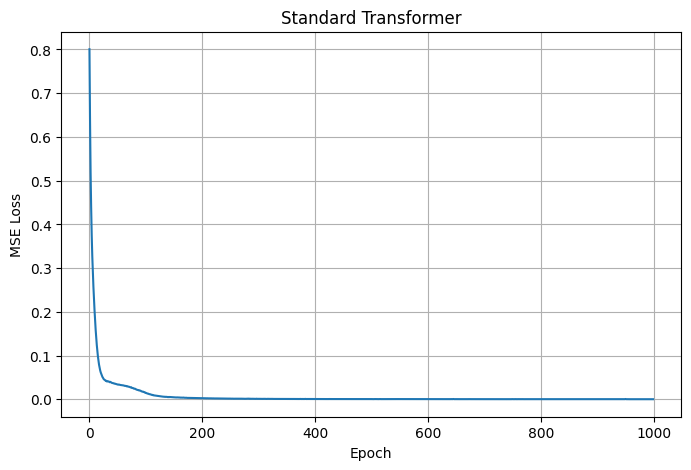

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load dataset
df = pd.read_csv("tdse_particle_in_box_reshaped.csv")

X = df[["t"]].values.astype(np.float32)
Y = df.drop(columns=["t"]).values.astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Train/Test split (temporal)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Convert to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# Standard Transformer
class WaveTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.d_model = 64

        # Input embedding
        self.embedding = nn.Linear(1, self.d_model)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Output layer
        self.output = nn.Linear(
            self.d_model,
            200
        )

    def forward(self, x):

        # x shape:
        # (batch_size, 1)
        x = self.embedding(x)

        # Add sequence dimension
        # (batch, seq_len=1, d_model)
        x = x.unsqueeze(1)

        x = self.transformer(x)

        # Remove sequence dimension
        x = x.squeeze(1)

        x = self.output(x)

        return x


model = WaveTransformer()

print(model)

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training
epochs = 1000

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(predictions, Y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss = {loss.item():.8f}"
        )

# Test evaluation
model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = criterion(
        test_predictions,
        Y_test
    )

print("\nTest MSE:")
print(test_loss.item())

# Probability checks
print("\nProbability checks:")

test_np = test_predictions.numpy()

dx = 1.0 / 99

for i in range(5):

    sample = test_np[i]

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    print(f"Sample {i}: P = {P:.6f}")

# Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Standard Transformer")

plt.grid(True)

plt.show()

## Transformer with hard constraint (One token problem)

X shape: (200, 1)
Y shape: (200, 200)

Train size: 160
Test size : 40
ProbabilityPreservingTransformer(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): Linear(in_features=64, out_features=200, bias=True)
)
Epoch    0 | Loss = 0.93611205
Epoch  100 | Loss = 0.02306585


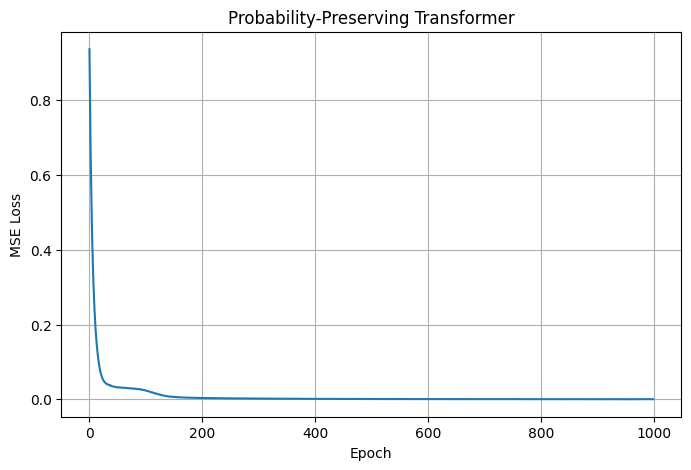

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load dataset
df = pd.read_csv("tdse_particle_in_box_reshaped.csv")

X = df[["t"]].values.astype(np.float32)
Y = df.drop(columns=["t"]).values.astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Train/Test split (temporal)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Convert to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)


# Probability-Preserving Transformer
class ProbabilityPreservingTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.d_model = 64
        self.dx = 1.0 / 99

        # Input embedding
        self.embedding = nn.Linear(1, self.d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Output layer
        self.output = nn.Linear(
            self.d_model,
            200
        )

    def forward(self, x):


        # Embedding
        x = self.embedding(x)

        # Sequence length = 1
        x = x.unsqueeze(1)

        # Transformer
        x = self.transformer(x)

        # Remove sequence dimension
        x = x.squeeze(1)

        # Raw prediction
        psi_hat = self.output(x)


        # Split into real and imaginary parts
        real = psi_hat[:, :100]
        imag = psi_hat[:, 100:]


        # Compute total probability
        probability = torch.sum(
            real**2 + imag**2,
            dim=1,
            keepdim=True
        ) * self.dx


        # Hard normalization
        normalization_factor = torch.sqrt(
            probability + 1e-12
        )

        real = real / normalization_factor
        imag = imag / normalization_factor

        # Recombine
        psi = torch.cat([real, imag], dim=1)

        return psi


model = ProbabilityPreservingTransformer()

print(model)

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training
epochs = 1000

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(predictions, Y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss = {loss.item():.8f}"
        )

# Test evaluation
model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = criterion(
        test_predictions,
        Y_test
    )

print("\nTest MSE:")
print(test_loss.item())

# Probability checks
print("\nProbability checks:")

test_np = test_predictions.numpy()

dx = 1.0 / 99

for i in range(5):

    sample = test_np[i]

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    print(f"Sample {i}: P = {P:.12f}")

# Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Probability-Preserving Transformer")

plt.grid(True)

plt.show()

##Baseline Transformer for Multi-Token System

X shape: (195, 5)
Y shape: (195, 200)

Train size: 156
Test size : 39
MultiTokenTransformer(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): Linear(in_features=64, out_features=200, bias=True)
)
Epoch    0 | Loss = 0.84605515
Epoch  100 | Loss = 0.02467460
Epoch  200 

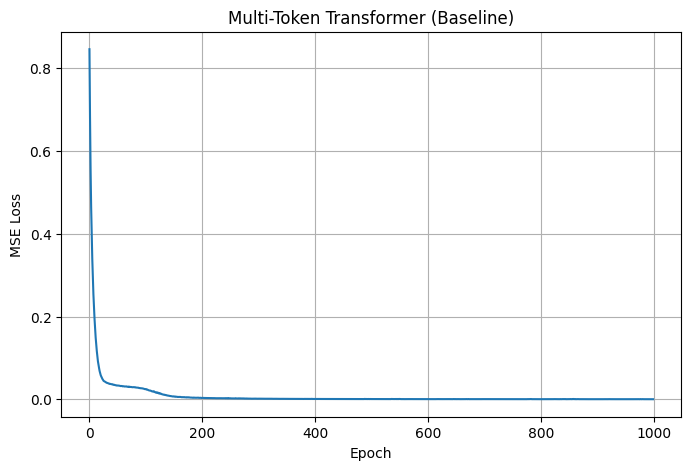

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load MULTI-TOKEN dataset
df = pd.read_csv(
    "tdse_particle_in_box_multitoken.csv"
)

time_cols = [f"t_{i}" for i in range(5)]

X = df[time_cols].values.astype(np.float32)

Y = df.drop(columns=time_cols).values.astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Expected: X -> (195, 5), Y -> (195, 200)

# Train/Test split (temporal)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)


# Multi-Token Transformer + Positional Encoding
class MultiTokenTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.d_model = 64
        self.seq_len = 5


        # Time embedding
        self.embedding = nn.Linear(1, self.d_model)


        # Learnable positional encoding, Shape: (1, 5, 64)
        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.seq_len, self.d_model)
        )


        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )


        # Output layer
        self.output = nn.Linear(
            self.d_model,
            200
        )


    def forward(self, x):

        # x shape: (batch_size, 5)

        # Convert each scalar time into a token
        x = x.unsqueeze(-1)

        # (batch, 5, 1) into (batch, 5, 64)
        x = self.embedding(x)


        # Add positional information
        x = x + self.pos_embedding

        # Self-attention
        x = self.transformer(x)

        # Use the last token representation
        x = x[:, -1, :]

        # Predict next wavefunction
        x = self.output(x)

        return x


model = MultiTokenTransformer()

print(model)

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# Training
epochs = 1000

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(
        predictions,
        Y_train
    )

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss = {loss.item():.8f}"
        )


# Test evaluation
model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = criterion(
        test_predictions,
        Y_test
    )

print("\nTest MSE:")
print(test_loss.item())


# Probability checks
print("\nProbability checks:")

test_np = test_predictions.numpy()

dx = 1.0 / 99

for i in range(5):

    sample = test_np[i]

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    print(f"Sample {i}: P = {P:.6f}")


# Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multi-Token Transformer (Baseline)")

plt.grid(True)

plt.show()

## Transformer model with hard constarint for multi-token system

X shape: (195, 5)
Y shape: (195, 200)

Train size: 156
Test size : 39
ProbabilityPreservingMultiTokenTransformer(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): Linear(in_features=64, out_features=200, bias=True)
)
Epoch    0 | Loss = 0.98691112
Epoch  100 | Loss = 0

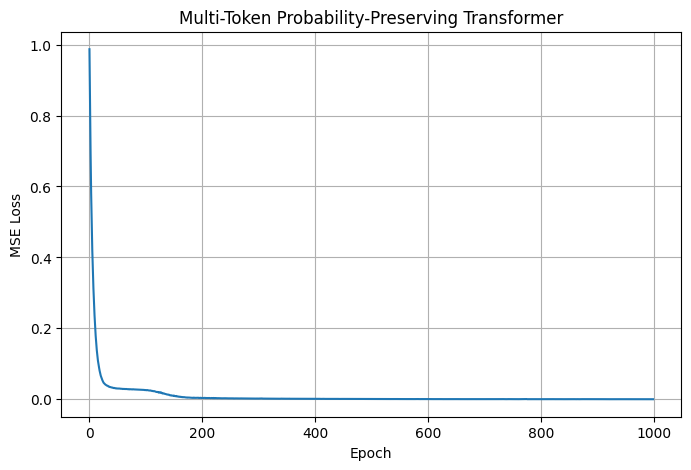

Input time window:
[0.156 0.157 0.158 0.159 0.16 ]

Reconstructed prediction:
       t         x  psi_real  psi_imag
0  0.161  0.000000  0.005368 -0.006694
1  0.161  0.010101  0.032064 -0.026419
2  0.161  0.020202  0.066722 -0.065260
3  0.161  0.030303  0.094336 -0.098191
4  0.161  0.040404  0.127894 -0.128705


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load MULTI-TOKEN dataset
df = pd.read_csv(
    "tdse_particle_in_box_multitoken.csv"
)

time_cols = [f"t_{i}" for i in range(5)]

X = df[time_cols].values.astype(np.float32)
Y = df.drop(columns=time_cols).values.astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Train/Test split (temporal split)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

# Multi-Token Probability-Preserving Transformer
class ProbabilityPreservingMultiTokenTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.d_model = 64
        self.seq_len = 5
        self.dx = 1.0 / 99


        # Time embedding
        self.embedding = nn.Linear(1, self.d_model)


        # Learnable positional encoding
        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.seq_len, self.d_model)
        )


        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )


        # Output layer
        self.output = nn.Linear(
            self.d_model,
            200
        )

    def forward(self, x):

        # x shape: (batch_size, 5)

        # Convert times into tokens
        x = x.unsqueeze(-1)

        # (batch, 5, 1) into (batch, 5, 64)
        x = self.embedding(x)


        # Add positional encoding
        x = x + self.pos_embedding


        # Self-attention
        x = self.transformer(x)

        # Use the final token
        x = x[:, -1, :]

        # Raw prediction
        psi_hat = self.output(x)

        # HARD PROBABILITY CONSTRAINT

        real = psi_hat[:, :100]
        imag = psi_hat[:, 100:]

        probability = torch.sum(
            real**2 + imag**2,
            dim=1,
            keepdim=True
        ) * self.dx

        normalization_factor = torch.sqrt(
            probability + 1e-12
        )

        real = real / normalization_factor
        imag = imag / normalization_factor

        psi = torch.cat(
            [real, imag],
            dim=1
        )

        return psi


model = ProbabilityPreservingMultiTokenTransformer()

print(model)

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training
epochs = 1000

train_losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    predictions = model(X_train)

    loss = criterion(
        predictions,
        Y_train
    )

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss = {loss.item():.8f}"
        )

# Test evaluation
model.eval()

with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = criterion(
        test_predictions,
        Y_test
    )

print("\nTest MSE:")
print(test_loss.item())

# Probability checks
print("\nProbability checks:")

test_np = test_predictions.numpy()

dx = 1.0 / 99

for i in range(5):

    sample = test_np[i]

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    print(f"Sample {i}: P = {P:.12f}")

# Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Multi-Token Probability-Preserving Transformer"
)

plt.grid(True)

plt.show()


# CONVERT PREDICTIONS BACK TO ORIGINAL FORMAT

# test sample want to inspect
sample_idx = 0

# Get the input time window
time_window = X_test[sample_idx].numpy()

print("Input time window:")
print(time_window)

# Example: [0.156 0.157 0.158 0.159 0.160]

# Predicted wavefunction
prediction = test_predictions[sample_idx].numpy()

# Split into real and imaginary parts
real_pred = prediction[:100]
imag_pred = prediction[100:]

# Spatial grid
x_positions = np.linspace(0, 1, 100)

# Time associated with this prediction
# In our dataset construction: [t0, t1, t2, t3, t4]  ---> predict wavefunction at t4, So we use the last token.
dt = 0.001
prediction_time = time_window[-1] + dt

# Create DataFrame in the ORIGINAL format
df_original_format = pd.DataFrame({

    "t": prediction_time,
    "x": x_positions,
    "psi_real": real_pred,
    "psi_imag": imag_pred

})

print("\nReconstructed prediction:")
print(df_original_format.head())

## Model Validation Check

ERROR METRICS
MSE  = 5.80112042e-04
RMSE = 2.40855161e-02
Relative L2 Error = 3.42336595e-02
Maximum Absolute Error = 7.44988918e-02

PROBABILITY CONSERVATION
Minimum P = 0.999999821186
Maximum P = 1.000000238419
Mean P    = 1.000000000000
Std P     = 1.032382712651e-07


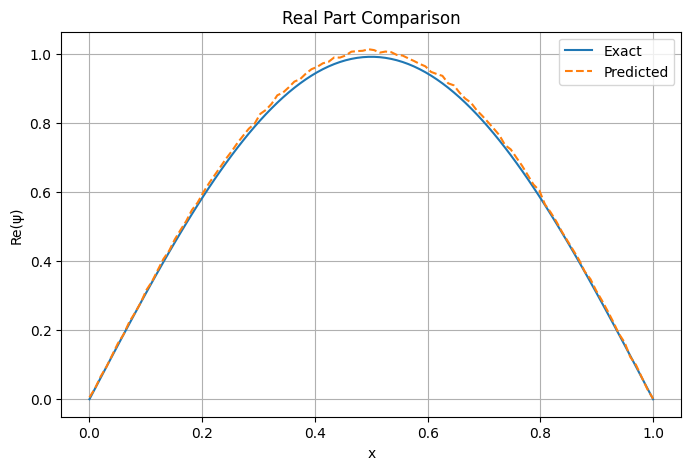

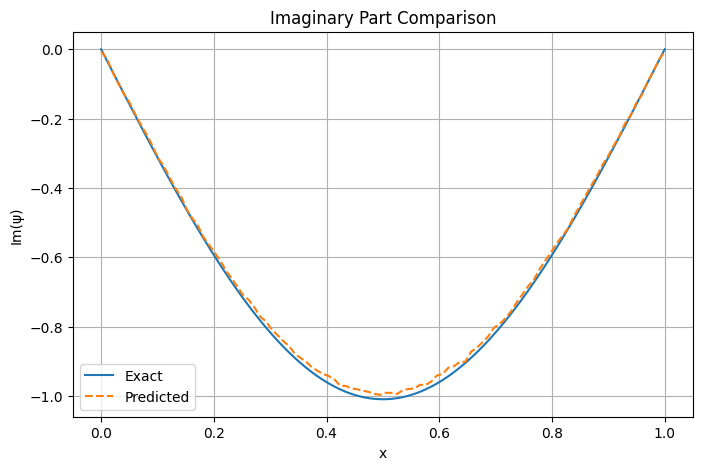

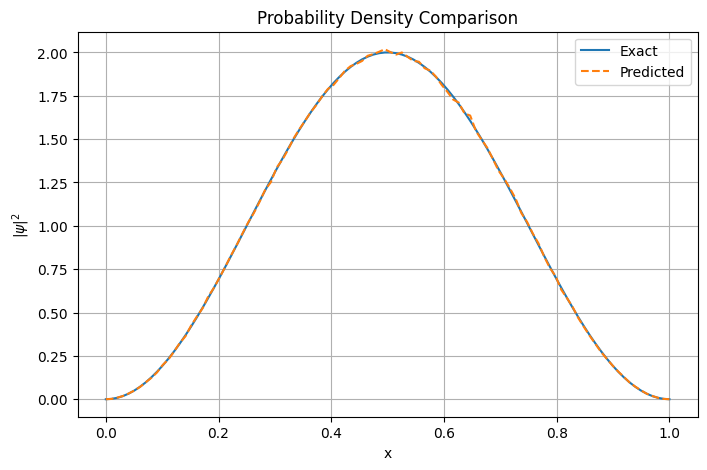

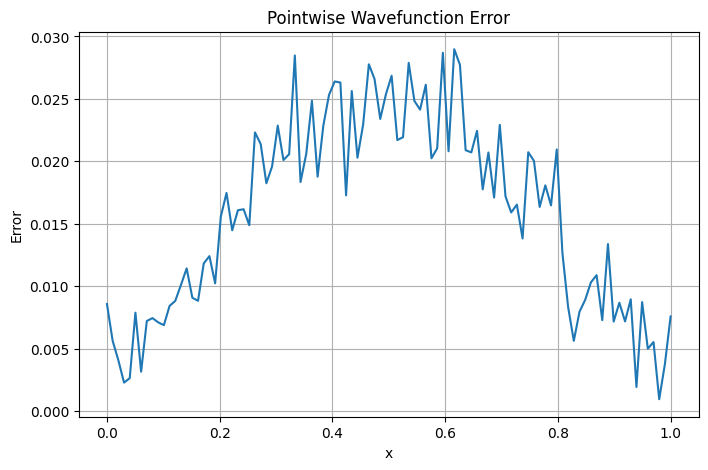

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert tensors to NumPy
y_true = Y_test.numpy()
y_pred = test_predictions.numpy()

dx = 1.0 / 99

# RMSE
mse = np.mean((y_true - y_pred)**2)
rmse = np.sqrt(mse)

print("="*50)
print("ERROR METRICS")
print("="*50)
print(f"MSE  = {mse:.8e}")
print(f"RMSE = {rmse:.8e}")

# Relative L2 Error
relative_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

print(f"Relative L2 Error = {relative_l2:.8e}")

# Maximum Absolute Error
max_error = np.max(np.abs(y_true - y_pred))

print(f"Maximum Absolute Error = {max_error:.8e}")


# Probability check on ALL test samples
probabilities = []

for sample in y_pred:

    real = sample[:100]
    imag = sample[100:]

    P = np.sum(real**2 + imag**2) * dx

    probabilities.append(P)

probabilities = np.array(probabilities)

print("\n" + "="*50)
print("PROBABILITY CONSERVATION")
print("="*50)

print(f"Minimum P = {probabilities.min():.12f}")
print(f"Maximum P = {probabilities.max():.12f}")
print(f"Mean P    = {probabilities.mean():.12f}")
print(f"Std P     = {probabilities.std():.12e}")


# Choose one test example
sample_idx = 0

true_sample = y_true[sample_idx]
pred_sample = y_pred[sample_idx]

# Split real and imaginary parts
real_true = true_sample[:100]
imag_true = true_sample[100:]

real_pred = pred_sample[:100]
imag_pred = pred_sample[100:]

# Spatial grid
x = np.linspace(0, 1, 100)


# Plot: Real part
plt.figure(figsize=(8,5))

plt.plot(x, real_true, label="Exact")
plt.plot(x, real_pred, "--", label="Predicted")

plt.xlabel("x")
plt.ylabel("Re(ψ)")
plt.title("Real Part Comparison")

plt.legend()
plt.grid(True)

plt.show()


# Plot: Imaginary part
plt.figure(figsize=(8,5))

plt.plot(x, imag_true, label="Exact")
plt.plot(x, imag_pred, "--", label="Predicted")

plt.xlabel("x")
plt.ylabel("Im(ψ)")
plt.title("Imaginary Part Comparison")

plt.legend()
plt.grid(True)

plt.show()


# Probability density
rho_true = real_true**2 + imag_true**2
rho_pred = real_pred**2 + imag_pred**2


# Plot: Probability density
plt.figure(figsize=(8,5))

plt.plot(x, rho_true, label="Exact")
plt.plot(x, rho_pred, "--", label="Predicted")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")

plt.title("Probability Density Comparison")

plt.legend()
plt.grid(True)

plt.show()


# Error distribution
pointwise_error = np.sqrt(
    (real_true - real_pred)**2 +
    (imag_true - imag_pred)**2
)

plt.figure(figsize=(8,5))

plt.plot(x, pointwise_error)

plt.xlabel("x")
plt.ylabel("Error")

plt.title("Pointwise Wavefunction Error")

plt.grid(True)

plt.show()